# EuroMillions ML – Análisis, Ingeniería de Características y Predicción Probabilística
Proyecto de demostración: análisis del histórico de Euromillones (2004–2025), construcción de *features* y un modelo base para estimar probabilidades por número/estrella. **Objetivo educativo**: mostrar buenas prácticas de *time-series validation* y evitar *data leakage*.


> **Nota**: Predecir la combinación exacta de un sorteo de lotería es esencialmente aleatorio. Este notebook no promete acertar resultados, **solo** ilustra técnicas de modelado y validación **aplicadas** a este dominio como ejercicio de ciencia de datos.

## Contenido
1. Carga de datos y EDA
2. Ingeniería de características (frecuencias, *gaps*, composición de la combinación)
3. Formulación del problema: estimar probabilidad marginal por número (1–50) y estrella (1–12)
4. Validación temporal (TimeSeriesSplit)
5. Entrenamiento con **LogisticRegression** por número/estrella
6. Evaluación: AUC media, *hit rate* @k (top‑k)
7. Predicción para el siguiente sorteo (ranking de números y estrellas)


In [3]:
!pip install pandas numpy matplotlib scikit-learn


import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import TimeSeriesSplit

# Regla para gráficos: matplotlib, 1 figura por gráfico, sin colores específicos
pd.set_option('display.max_columns', 100)
CSV_PATH = r"D:\Proyectos Python\Loterias\euromillones_clean.csv"
df = pd.read_csv(CSV_PATH, parse_dates=["draw_date"]).sort_values("draw_date").reset_index(drop=True)
df.head()


,draw_no,draw_date,ball1,ball2,ball3,ball4,ball5,star1,star2,jackpot_eur,category1_winners,draw_id,dow,year,month
0,1,2004-02-13,16,29,32,36,41,7,9,10143000,1,1,4,2004,2
1,2,2004-02-20,7,13,39,47,50,2,5,10111500,0,2,4,2004,2
2,3,2004-02-27,14,18,19,31,37,4,5,11880304,0,3,4,2004,2
3,4,2004-03-05,4,7,33,37,39,1,5,13870849,1,4,4,2004,3
4,5,2004-03-12,15,24,28,44,47,4,5,10171500,0,5,4,2004,3


## 1) EDA básica

In [4]:

# Dimensiones y rango temporal
n = len(df)
print("Registros:", n)
print("Rango de fechas:", df['draw_date'].min().date(), "→", df['draw_date'].max().date())

# Comprobación de duplicados
dups = df.duplicated(subset=['draw_date','ball1','ball2','ball3','ball4','ball5','star1','star2']).sum()
print("Duplicados exactos:", dups)

# Distribución de día de semana
(df['dow'].value_counts().sort_index().rename(index={0:'Lun',1:'Mar',2:'Mié',3:'Jue',4:'Vie',5:'Sáb',6:'Dom'}))


Registros: 1880
Rango de fechas: 2004-02-13 → 2025-09-26
Duplicados exactos: 0


dow
Mar     751
Vie    1129
Name: count, dtype: int64

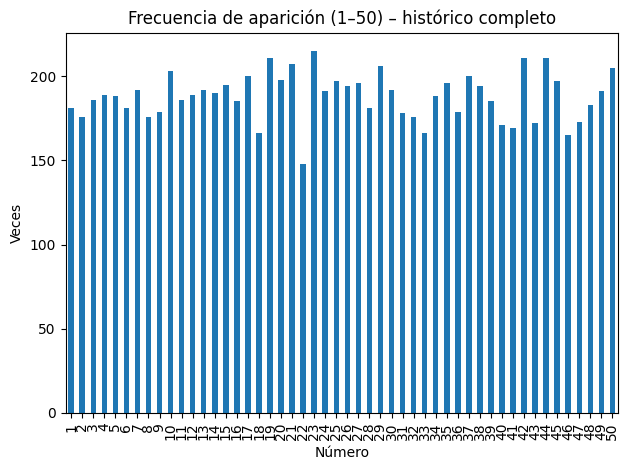

(1     181
 2     176
 3     186
 4     189
 5     188
 6     181
 7     192
 8     176
 9     179
 10    203
 Name: count, dtype: int64,
 41    169
 42    211
 43    172
 44    211
 45    197
 46    165
 47    173
 48    183
 49    191
 50    205
 Name: count, dtype: int64)

In [5]:

# Frecuencia bruta de números (bolas) en todo el histórico
balls = df[['ball1','ball2','ball3','ball4','ball5']].values
all_balls = pd.Series(balls.ravel())
freq_balls = all_balls.value_counts().sort_index()

plt.figure()
freq_balls.plot(kind='bar')
plt.title('Frecuencia de aparición (1–50) – histórico completo')
plt.xlabel('Número')
plt.ylabel('Veces')
plt.tight_layout()
plt.show()

freq_balls.head(10), freq_balls.tail(10)


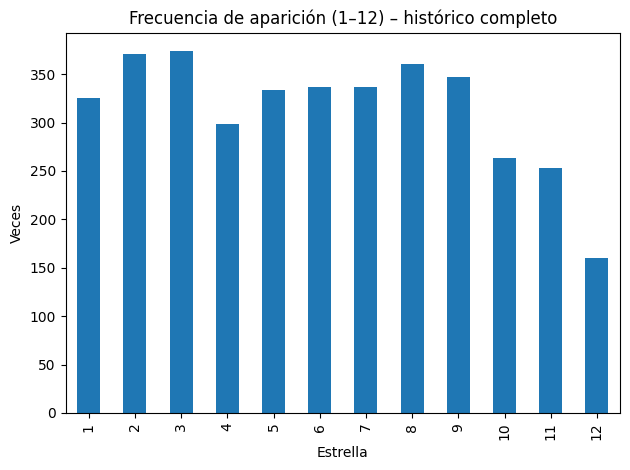

1     325
2     371
3     374
4     299
5     334
6     337
7     337
8     360
9     347
10    263
11    253
12    160
Name: count, dtype: int64

In [6]:

# Frecuencia bruta de estrellas
stars = df[['star1','star2']].values
all_stars = pd.Series(stars.ravel())
freq_stars = all_stars.value_counts().sort_index()

plt.figure()
freq_stars.plot(kind='bar')
plt.title('Frecuencia de aparición (1–12) – histórico completo')
plt.xlabel('Estrella')
plt.ylabel('Veces')
plt.tight_layout()
plt.show()

freq_stars


## 2) Ingeniería de características

In [7]:

# --- Ingeniería de características por "draw-number" (formato largo) ---
# Construimos un dataset con filas = (sorteo, número) para 1..50, label=1 si salió en ese sorteo.
# Features: frecuencia en últimas 50/200 extracciones, gap (días desde última aparición), mes, día de semana, etc.

def build_long_format(df, max_number=50, window_short=50, window_long=200):
    df = df.copy()
    df['draw_idx'] = np.arange(len(df))  # índice temporal
    # Matriz de etiquetas (n_draws x max_number): 1 si la bola "num" está en el sorteo i
    labels = np.zeros((len(df), max_number), dtype=int)
    for i, row in df.iterrows():
        nums = [row['ball1'],row['ball2'],row['ball3'],row['ball4'],row['ball5']]
        for num in nums:
            labels[i, int(num)-1] = 1

    # Cálculo rolling de frecuencias y gaps
    # freqs_short[i, num-1] = apariciones de num en los últimos 'window_short' sorteos previos a i
    freqs_short = np.zeros_like(labels, dtype=float)
    freqs_long = np.zeros_like(labels, dtype=float)
    last_seen = np.full((max_number,), -1, dtype=int)  # última vez que apareció cada número
    gaps = np.zeros_like(labels, dtype=float)

    for i in range(len(df)):
        # actualizar gaps con la última posición conocida
        for num in range(1, max_number+1):
            prev = last_seen[num-1]
            gaps[i, num-1] = (i - prev) if prev >= 0 else np.nan

        # calcular frecuencias en ventanas con datos previos (no incluir el sorteo actual)
        i0_short = max(0, i - window_short)
        i0_long = max(0, i - window_long)
        prev_labels_short = labels[i0_short:i, :]
        prev_labels_long  = labels[i0_long:i, :]
        if prev_labels_short.size > 0:
            freqs_short[i, :] = prev_labels_short.sum(axis=0) / max(1, prev_labels_short.shape[0])
        if prev_labels_long.size > 0:
            freqs_long[i, :] = prev_labels_long.sum(axis=0) / max(1, prev_labels_long.shape[0])

        # al final del bucle, actualizar last_seen con el sorteo actual
        for num in range(1, max_number+1):
            if labels[i, num-1] == 1:
                last_seen[num-1] = i

    # Construir dataframe largo
    recs = []
    for i in range(len(df)):
        for num in range(1, max_number+1):
            recs.append({
                "draw_idx": i,
                "draw_date": df.loc[i, "draw_date"],
                "year": int(df.loc[i, "year"]),
                "month": int(df.loc[i, "month"]),
                "dow": int(df.loc[i, "dow"]),
                "number": num,
                "y": int(labels[i, num-1]),
                "freq_50": float(freqs_short[i, num-1]),
                "freq_200": float(freqs_long[i, num-1]),
                "gap": float(gaps[i, num-1]),
            })
    long_df = pd.DataFrame(recs)
    # Al principio habrá NaN en gap; rellenar con un valor grande para indicar "no visto"
    long_df['gap'] = long_df['gap'].fillna(long_df['gap'].max() + 10)
    return long_df

long_balls = build_long_format(df, max_number=50, window_short=50, window_long=200)
long_balls.head()


,draw_idx,draw_date,year,month,dow,number,y,freq_50,freq_200,gap
0,0,2004-02-13,2004,2,4,1,0,0.0,0.0,98.0
1,0,2004-02-13,2004,2,4,2,0,0.0,0.0,98.0
2,0,2004-02-13,2004,2,4,3,0,0.0,0.0,98.0
3,0,2004-02-13,2004,2,4,4,0,0.0,0.0,98.0
4,0,2004-02-13,2004,2,4,5,0,0.0,0.0,98.0


In [8]:

# Repetimos el mismo proceso para estrellas (1–12), con label=1 si esa estrella salió en el sorteo
def build_long_format_stars(df, max_star=12, window_short=50, window_long=200):
    df = df.copy()
    df['draw_idx'] = np.arange(len(df))
    labels = np.zeros((len(df), max_star), dtype=int)
    for i, row in df.iterrows():
        nums = [row['star1'], row['star2']]
        for num in nums:
            labels[i, int(num)-1] = 1

    freqs_short = np.zeros_like(labels, dtype=float)
    freqs_long = np.zeros_like(labels, dtype=float)
    last_seen = np.full((max_star,), -1, dtype=int)
    gaps = np.zeros_like(labels, dtype=float)

    for i in range(len(df)):
        for num in range(1, max_star+1):
            prev = last_seen[num-1]
            gaps[i, num-1] = (i - prev) if prev >= 0 else np.nan

        i0_short = max(0, i - window_short)
        i0_long = max(0, i - window_long)
        prev_labels_short = labels[i0_short:i, :]
        prev_labels_long  = labels[i0_long:i, :]
        if prev_labels_short.size > 0:
            freqs_short[i, :] = prev_labels_short.sum(axis=0) / max(1, prev_labels_short.shape[0])
        if prev_labels_long.size > 0:
            freqs_long[i, :] = prev_labels_long.sum(axis=0) / max(1, prev_labels_long.shape[0])

        for num in range(1, max_star+1):
            if labels[i, num-1] == 1:
                last_seen[num-1] = i

    recs = []
    for i in range(len(df)):
        for num in range(1, max_star+1):
            recs.append({
                "draw_idx": i,
                "draw_date": df.loc[i, "draw_date"],
                "year": int(df.loc[i, "year"]),
                "month": int(df.loc[i, "month"]),
                "dow": int(df.loc[i, "dow"]),
                "star": num,
                "y": int(labels[i, num-1]),
                "freq_50": float(freqs_short[i, num-1]),
                "freq_200": float(freqs_long[i, num-1]),
                "gap": float(gaps[i, num-1]),
            })
    long_df = pd.DataFrame(recs)
    long_df['gap'] = long_df['gap'].fillna(long_df['gap'].max() + 10)
    return long_df

long_stars = build_long_format_stars(df, max_star=12, window_short=50, window_long=200)
long_stars.head()


,draw_idx,draw_date,year,month,dow,star,y,freq_50,freq_200,gap
0,0,2004-02-13,2004,2,4,1,0,0.0,0.0,51.0
1,0,2004-02-13,2004,2,4,2,0,0.0,0.0,51.0
2,0,2004-02-13,2004,2,4,3,0,0.0,0.0,51.0
3,0,2004-02-13,2004,2,4,4,0,0.0,0.0,51.0
4,0,2004-02-13,2004,2,4,5,0,0.0,0.0,51.0


## 3) Modelado y validación temporal

In [9]:

# --- Modelado por número: LogisticRegression con validación temporal ---
def train_eval_logreg(long_df, feature_cols, label_col='y', entity_col='number', splits=5, min_train_size=500):
    tscv = TimeSeriesSplit(n_splits=splits)
    aucs = []
    hit_rates = []  # top-k hit rate por sorteo (k=5 para bolas)
    k = 5
    last_fold = None

    # Preparamos por "draw_idx": en cada fold, para cada sorteo del test, rankeamos números por probabilidad
    for fold, (train_idx, test_idx) in enumerate(tscv.split(long_df['draw_idx'].unique())):
        train_draws = long_df['draw_idx'].unique()[train_idx]
        test_draws  = long_df['draw_idx'].unique()[test_idx]
        if len(train_draws) < min_train_size:
            continue

        train = long_df[long_df['draw_idx'].isin(train_draws)]
        test  = long_df[long_df['draw_idx'].isin(test_draws)]

        X_train = train[feature_cols].values
        y_train = train[label_col].values
        X_test  = test[feature_cols].values
        y_test  = test[label_col].values

        clf = LogisticRegression(max_iter=200, class_weight='balanced', n_jobs=None)
        clf.fit(X_train, y_train)
        proba = clf.predict_proba(X_test)[:,1]

        # AUC global del fold
        try:
            auc = roc_auc_score(y_test, proba)
            aucs.append(auc)
        except Exception:
            pass

        # Hit rate @k: por cada sorteo del test, tomamos top-k números según proba y miramos cuántos aciertos
        test = test.copy()
        test['proba'] = proba
        for d in sorted(test['draw_idx'].unique()):
            slice_d = test[test['draw_idx'] == d]
            topk = slice_d.sort_values('proba', ascending=False).head(k)['number'].tolist()
            # Números realmente sorteados en d
            # Para obtener la verdad de ese sorteo usamos el dataframe original df
            balls = set(df.loc[d, ['ball1','ball2','ball3','ball4','ball5']].values.tolist())
            hits = len(balls.intersection(topk))
            hit_rates.append(hits/5.0)

        last_fold = clf

    results = {
        "auc_mean": float(np.mean(aucs)) if aucs else None,
        "auc_std": float(np.std(aucs)) if aucs else None,
        "hit_rate_mean": float(np.mean(hit_rates)) if hit_rates else None,
        "hit_rate_std": float(np.std(hit_rates)) if hit_rates else None,
        "model": last_fold
    }
    return results

ball_features = ["freq_50","freq_200","gap","year","month","dow"]
res_balls = train_eval_logreg(long_balls, ball_features, label_col="y", entity_col="number", splits=6, min_train_size=400)
res_balls


{'auc_mean': 0.4971826934976856,
 'auc_std': 0.01092310796406325,
 'hit_rate_mean': 0.0953731343283582,
 'hit_rate_std': 0.12699545600296047,
 'model': LogisticRegression(class_weight='balanced', max_iter=200)}

In [10]:

# --- Modelado para estrellas: k=2 en métrica de acierto ---
def train_eval_logreg_stars(long_df, feature_cols, label_col='y', entity_col='star', splits=5, min_train_size=400):
    tscv = TimeSeriesSplit(n_splits=splits)
    aucs = []
    hit_rates = []  # top-k hit rate por sorteo (k=2 para estrellas)
    k = 2
    last_fold = None

    for fold, (train_idx, test_idx) in enumerate(tscv.split(long_df['draw_idx'].unique())):
        train_draws = long_df['draw_idx'].unique()[train_idx]
        test_draws  = long_df['draw_idx'].unique()[test_idx]
        if len(train_draws) < min_train_size:
            continue

        train = long_df[long_df['draw_idx'].isin(train_draws)]
        test  = long_df[long_df['draw_idx'].isin(test_draws)]

        X_train = train[feature_cols].values
        y_train = train[label_col].values
        X_test  = test[feature_cols].values
        y_test  = test[label_col].values

        clf = LogisticRegression(max_iter=200, class_weight='balanced', n_jobs=None)
        clf.fit(X_train, y_train)
        proba = clf.predict_proba(X_test)[:,1]

        try:
            auc = roc_auc_score(y_test, proba)
            aucs.append(auc)
        except Exception:
            pass

        test = test.copy()
        test['proba'] = proba
        for d in sorted(test['draw_idx'].unique()):
            slice_d = test[test['draw_idx'] == d]
            topk = slice_d.sort_values('proba', ascending=False).head(k)['star'].tolist()
            stars_real = set(df.loc[d, ['star1','star2']].values.tolist())
            hits = len(stars_real.intersection(topk))
            hit_rates.append(hits/2.0)

        last_fold = clf

    results = {
        "auc_mean": float(np.mean(aucs)) if aucs else None,
        "auc_std": float(np.std(aucs)) if aucs else None,
        "hit_rate_mean": float(np.mean(hit_rates)) if hit_rates else None,
        "hit_rate_std": float(np.std(hit_rates)) if hit_rates else None,
        "model": last_fold
    }
    return results

star_features = ["freq_50","freq_200","gap","year","month","dow"]
res_stars = train_eval_logreg_stars(long_stars, star_features, label_col="y", entity_col="star", splits=6, min_train_size=400)
res_stars


{'auc_mean': 0.5130367286700823,
 'auc_std': 0.01803767002212881,
 'hit_rate_mean': 0.16977611940298507,
 'hit_rate_std': 0.25056046554156075,
 'model': LogisticRegression(class_weight='balanced', max_iter=200)}

## 4) Predicción para el siguiente sorteo

Top‑5 bolas (ranking probabilístico): [11, 33, 29, 24, 13]
Top‑2 estrellas (ranking probabilístico): [9, 12]


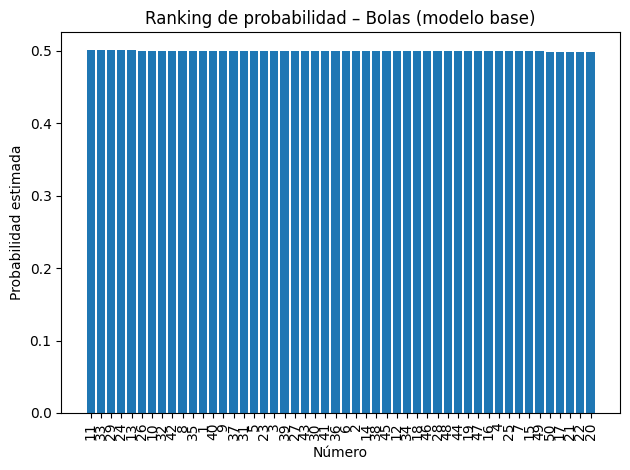

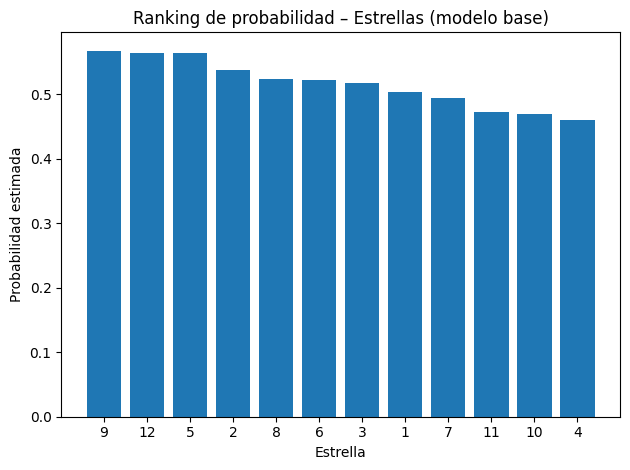

(    number  freq_50  freq_200  gap  year  month  dow     proba
 10      11     0.02     0.080  1.0  2025      9    4  0.500646
 32      33     0.10     0.110  1.0  2025      9    4  0.500646
 28      29     0.14     0.135  1.0  2025      9    4  0.500646
 23      24     0.16     0.125  1.0  2025      9    4  0.500646
 12      13     0.20     0.135  1.0  2025      9    4  0.500646
 25      26     0.04     0.055  2.0  2025      9    4  0.500578
 9       10     0.08     0.120  2.0  2025      9    4  0.500578
 31      32     0.10     0.080  2.0  2025      9    4  0.500578
 41      42     0.14     0.125  2.0  2025      9    4  0.500578
 7        8     0.14     0.125  2.0  2025      9    4  0.500578,
     star  freq_50  freq_200  gap  year  month  dow     proba
 8      9     0.18     0.210  2.0  2025      9    4  0.567952
 11    12     0.20     0.205  2.0  2025      9    4  0.564113
 4      5     0.26     0.195  1.0  2025      9    4  0.563980
 1      2     0.16     0.155  1.0  2025      9 

In [11]:

# --- Predicción para el siguiente sorteo ---
# Usamos todos los datos disponibles para calcular features del "próximo" sorteo (draw_idx = len(df))
def next_features_from_long(long_df, entity_col, feature_cols):
    # Tomamos la última fila por entidad (mismo draw_idx final) ya que nuestro builder define features
    # en cada draw_idx. Para el siguiente, usamos la última fila existente como estado actual.
    latest_idx = long_df['draw_idx'].max()
    latest = long_df[long_df['draw_idx'] == latest_idx].copy()
    return latest[[entity_col] + feature_cols].reset_index(drop=True)

# Reentrenamos modelos con todo el histórico para estimar probs actuales
clf_balls = LogisticRegression(max_iter=300, class_weight='balanced')
Xb = long_balls[ball_features].values
yb = long_balls['y'].values
clf_balls.fit(Xb, yb)
Xb_next = next_features_from_long(long_balls, 'number', ball_features)
probs_balls = clf_balls.predict_proba(Xb_next[ball_features].values)[:,1]
ranking_balls = Xb_next.assign(proba=probs_balls).sort_values('proba', ascending=False)

clf_stars = LogisticRegression(max_iter=300, class_weight='balanced')
Xs = long_stars[star_features].values
ys = long_stars['y'].values
clf_stars.fit(Xs, ys)
Xs_next = next_features_from_long(long_stars, 'star', star_features)
probs_stars = clf_stars.predict_proba(Xs_next[star_features].values)[:,1]
ranking_stars = Xs_next.assign(proba=probs_stars).sort_values('proba', ascending=False)

top5 = ranking_balls.head(5)['number'].tolist()
top2 = ranking_stars.head(2)['star'].tolist()

print("Top‑5 bolas (ranking probabilístico):", top5)
print("Top‑2 estrellas (ranking probabilístico):", top2)

# Visualización simple de rankings
plt.figure()
plt.bar(ranking_balls['number'].astype(str).values, ranking_balls['proba'].values)
plt.title('Ranking de probabilidad – Bolas (modelo base)')
plt.xlabel('Número')
plt.ylabel('Probabilidad estimada')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

plt.figure()
plt.bar(ranking_stars['star'].astype(str).values, ranking_stars['proba'].values)
plt.title('Ranking de probabilidad – Estrellas (modelo base)')
plt.xlabel('Estrella')
plt.ylabel('Probabilidad estimada')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

ranking_balls.head(10), ranking_stars.head(10)



## Conclusiones
- Este flujo **no** predice combinaciones exactas; solo asigna **probabilidad marginal** a cada número/estrella.
- La métrica **hit rate @k** y la **AUC** ofrecen una referencia de si el ranking aporta algo frente a aleatorio.
- Mejoras posibles:
  - Más *features*: tendencia exponencial, *streaks*, varianza en ventanas, co‑ocurrencias (pares de números).
  - Modelos: Gradient Boosting / XGBoost / LightGBM; calibración de probabilidades.
  - *Ensembling* y *stacking* entre modelos de bolas y estrellas.
  - Backtesting con **bloques temporales** más finos y *walk‑forward validation*.
